<a href="https://colab.research.google.com/github/RogerVin1/Assigment1-DeepLearnig/blob/main/assigment1DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 0

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.draw import ellipse

Objetos por imagem (200 amostras): min=5, media=12.5, max=20


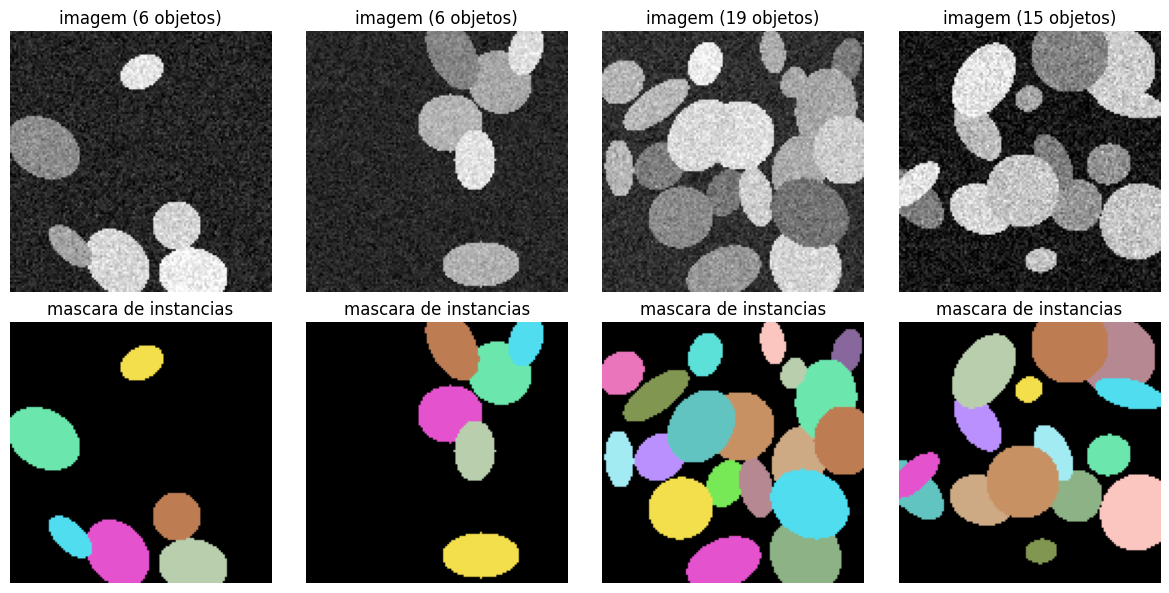

In [4]:
# Desenhar uma elipse como uma mascara booleana
def _mascara_de_uma_elipse(size, cy, cx, ry, rx, angulo):
    """
    Retorna um array booleano (size x size) com True dentro da elipse
    """

    mask = np.zeros((size, size), dtype=bool)
    rr, cc = ellipse(cy, cx, ry, rx, shape=(size, size), rotation=angulo)
    mask[rr, cc] = True
    return mask

# Gerar uma amostra
def gerar_amostra(size=128,
                  min_elipses=5,
                  max_elipses=20,
                  raio_min=6,
                  raio_max=20,
                  taxa_min_manter=0.55,
                  rng=None):
    """
    Gera uma imagem sintetica e sua mascara de instancias
    """
    if rng is None:
        rng = np.random.default_rng()

    # guarda o ID da instancia de cada pixel
    inst_mask = np.zeros((size, size), dtype=np.int32)
    proximo_id = 1

    n_elipses = int(rng.integers(min_elipses, max_elipses + 1))

    colocadas = 0
    max_tentativas = n_elipses * 12
    tentativas = 0

    while colocadas < n_elipses and tentativas < max_tentativas:
        tentativas += 1

        # sorteia a geometria da elipse
        cy = rng.integers(raio_min, size - raio_min)
        cx = rng.integers(raio_min, size - raio_min)
        ry = rng.integers(raio_min, raio_max + 1)
        rx = rng.integers(raio_min, raio_max + 1)
        angulo = rng.uniform(0, np.pi)

        cand = _mascara_de_uma_elipse(size, cy, cx, ry, rx, angulo)
        area_total = cand.sum()
        if area_total == 0:
            continue

        # so ficamos com os pixels que AINDA sao fundo
        livre = cand & (inst_mask == 0)
        if livre.sum() / area_total < taxa_min_manter:
            # sobrou pouco desta elipse então descarta e tenta outra posicao
            continue

        inst_mask[livre] = proximo_id
        proximo_id += 1
        colocadas += 1

    # constrói a imagem em tons de cinza a partir das instâncias
    image = _renderizar_imagem(inst_mask, rng)

    return image, inst_mask

# Transformar a mascara de instancias numa imagem "de microscopia"
def _renderizar_imagem(inst_mask, rng):
    """
    Pinta cada instancia com um tom de cinza proprio (contraste variavel entre
    objetos), coloca um fundo escuro variavel, e adiciona ruido gaussiano.
    """
    size = inst_mask.shape[0]

    # fundo escuro, com nivel variando de imagem para imagem (contraste global)
    nivel_fundo = rng.uniform(0.05, 0.20)
    image = np.full((size, size), nivel_fundo, dtype=np.float32)

    # cada instancia recebe um brilho proprio
    ids = np.unique(inst_mask)
    ids = ids[ids != 0]

    for i in ids:
        brilho = rng.uniform(0.45, 0.95)
        image[inst_mask == i] = brilho

    # ruido gaussiano
    sigma = rng.uniform(0.02, 0.12)
    image = image + rng.normal(0, sigma, size=image.shape)

    # mantem tudo no intervalo valido [0, 1]
    image = np.clip(image, 0.0, 1.0).astype(np.float32)

    return image

# Utilitario: colorir a mascara de instancias (so para visualizar)
def colorir_instancias(inst_mask, rng=None):
    """
    Devolve uma imagem RGB (size, size, 3) onde cada instancia tem uma cor
    aleatoria distinta e o fundo e preto. Serve so para inspecao visual.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    size = inst_mask.shape[0]
    rgb = np.zeros((size, size, 3), dtype=np.float32)
    ids = np.unique(inst_mask)
    ids = ids[ids != 0]

    for i in ids:
        cor = rng.uniform(0.3, 1.0, size=3)
        rgb[inst_mask == i] = cor

    return rgb

if __name__ == "__main__":

    rng = np.random.default_rng(42)

    n_mostrar = 4
    fig, axes = plt.subplots(2, n_mostrar, figsize=(3 * n_mostrar, 6))

    for col in range(n_mostrar):
        image, inst_mask = gerar_amostra(rng=rng)
        n_obj = len(np.unique(inst_mask)) - 1

        axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"imagem ({n_obj} objetos)")
        axes[0, col].axis("off")

        axes[1, col].imshow(colorir_instancias(inst_mask))
        axes[1, col].set_title("mascara de instancias")
        axes[1, col].axis("off")

    plt.tight_layout()

    contagens = []
    r2 = np.random.default_rng(0)
    for _ in range(200):
        _, m = gerar_amostra(rng=r2)
        contagens.append(len(np.unique(m)) - 1)
    contagens = np.array(contagens)
    print(f"Objetos por imagem (200 amostras): "
          f"min={contagens.min()}, media={contagens.mean():.1f}, max={contagens.max()}")